# Exercise 4. Classification, shallow learning

The aim of this exercise is to train 2 different shallow learning models to predict different land-use classes from satellite data. It also assesses the model accuracy with a test dataset.

## Input data

2 raster files with:

* Coordinate system: Finnish ETRS-TM35FIN, EPSG:3067
* Resolution: 20m

#### Labels

* Multiclass classification raster: 1 - forest, 2 - fields, 3 - water, 4 - urban, 0 - everything else.

#### Data image

* Sentinel2 mosaic, with data from 2 different dates (May and July), to have more data values. Dataset has 8 bands based on bands: 2, 3, 4 and 8 on dates: 2021-05-11 and 2021-07-21, reflection values scaled to [0 ... 1]. The bands source data is: 
     *  'b02' / '2021-05-11'
     *  'b02' / '2021-07-21'
     *  'b03' / '2021-05-11'
     *  'b03' / '2021-07-21'
     *  'b04' / '2021-05-11'
     *  'b04' / '2021-07-21'
     *  'b08' / '2021-05-11'
     *  'b08' / '2021-07-21'
     
[Bands](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/bands/): b02=blue, b03=green, b04=red, b08=infrared     

## Results

The trained models: 
* Random forest
* Stochastic Gradient Decent

For each model:
* Trained model
* Model accuracy estimation
* Class confusion matrix
* Predicted image

## Main steps

1) Read data and shape it to suitable form for scikit-learn.
2) Divide the data to training, validation and test datasets.
3) Undersample to balance the training dataset.
4) For each model:
   * Train the model.
   * Estimate the model on test data, inc class confusion matrix classification report creation.
   * Predict classification based on the data image and save it.
5) For SVM use grid search to find optimal settings.
6) Plot the results

## 4.0 Imports and paths

In [1]:
import os, time
from imblearn.under_sampling import RandomUnderSampler
from joblib import dump, load
import matplotlib.pyplot as plt
import matplotlib.colors
import numpy as np
import rasterio
import urllib
from rasterio.plot import show
from rasterio.plot import show_hist
from rasterio.windows import from_bounds
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
%matplotlib inline

In [2]:
### File paths.
# Source data URLs
image_url = 'https://a3s.fi/gis-courses/gis_ml/image.tif'
multiclass_classification_url = 'https://a3s.fi/gis-courses/gis_ml/labels_multiclass.tif'

# Folders
user = os.environ.get('USER')
base_folder = os.path.join('/scratch/project_462001167/students', user, 'GeoML')
dataFolder = os.path.join(base_folder,'data/raster')
outputBaseFolder= os.path.join(base_folder,'04_shallow_classification')

# Source data local paths
image_file = os.path.join(dataFolder, 'data_shallow.tif')
multiclass_classification_file = os.path.join(dataFolder, 'labels_shallow.tif')

# Available cores. During the course only 1 core is available, outside of this course more cores might be available 
# You can make use of multiple cores by setting this number to the number of cores available.
n_jobs = len(os.sched_getaffinity(0))

(Download input data if needed.)

In [3]:
if not os.path.isdir(dataFolder):
    os.makedirs(dataFolder)

## 4.1 Read data and shape it to suitable form for scikit-learn

Read the input datasets with Rasterio and shape it to suitable form for scikit-learn.

Exactly the same as for K-means for image data, the similar processing only added for the labels image.

### Satellite image

The satellite image has 8 channels, so rasterio reads it in as 3D data cube.

For scikit-learn we reshape the data to 2D, having in dataframe one row for each pixel. Each pixel has eight values, one for each band/date.

In [4]:
# Read the pixel values from .tif file as dataframe
with rasterio.open(image_file) as image_dataset:
    image_data = image_dataset.read()

# Check shape of input data
print ('Dataframe original shape, 3D: ', image_data.shape)    

Dataframe original shape, 3D:  (8, 1000, 1000)


Save number of bands for later, to be able to reshape data back to 2D.

In [5]:
no_bands_in_image = image_data.shape[0]
no_bands_in_image

8

As a mid-step transponse the axis order, so that the bands are the last. Notice how the dataframe size changes.

In [6]:
image_data2 = np.transpose(image_data, (1, 2, 0))
# Check again the data shape, now the bands should be last.
print ('Dataframe shape after transpose, 3D: ', image_data2.shape) 

Dataframe shape after transpose, 3D:  (1000, 1000, 8)


In [7]:
# Then reshape to 2D.
pixels = image_data2.reshape(-1, no_bands_in_image)
print ('Dataframe shape after transpose and reshape, 2D: ', pixels.shape) 

Dataframe shape after transpose and reshape, 2D:  (1000000, 8)


### Labels
Do the same for labels.

In [8]:
# For labels only reshape to 1D is enough.
with rasterio.open(multiclass_classification_file) as labels_src:
    labels_data = labels_src.read()
    input_labels = labels_data.reshape(-1)
    print ('Labels shape after reshape, 1D: ', input_labels.shape)

Labels shape after reshape, 1D:  (1000000,)


Notice that labels data has only one band.

In [9]:
labels_data.shape

(1, 1000, 1000)

## 4.2 Divide the data to training, validation and test datasets

Set training, validation and test data ratios, how big part of the pixels is assigned to different sets.

In [10]:
train_ratio = 0.7
validation_ratio = 0.2
test_ratio = 0.1

First separate test set.

In [11]:
x_rest, x_test, y_rest, y_test = train_test_split(pixels, input_labels, test_size=test_ratio, random_state=63, stratify=input_labels)

... and then training and validation set, using the ratios set above and keeping class representation the same in all sets.

In [12]:
x_train1, x_validation, y_train1, y_validation= train_test_split(x_rest, y_rest, test_size=validation_ratio/(train_ratio + validation_ratio), random_state=63, stratify=y_rest)

## 4.3 Resample to balance the dataset

The classes are very imbalanced in the dataset, so undersample the majority classes in the training set, so that all classes are represented about similar number of pixels. 
Notice that validation and test set keep the original class-distribution.

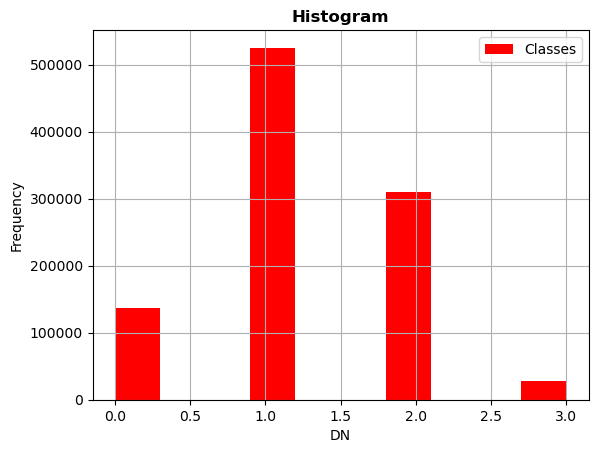

In [13]:
a = show_hist(labels_data, label='Classes')

In [14]:
rus = RandomUnderSampler(random_state=63)
x_train, y_train = rus.fit_resample(x_train1, y_train1)   
print ('Dataframe shape after undersampling of majority classes, 2D: ', x_train.shape)

Dataframe shape after undersampling of majority classes, 2D:  (77816, 8)


*How many pixels of different classes are included in training dataset?*

Notice that we lost a lot of pixel at this point, in real cases that may be undesired. See [inbalanced-learn User guide](https://imbalanced-learn.org/stable/user_guide.html#user-guide) for other options.

In [15]:
print('Labels before splitting:           ', np.unique(input_labels, return_counts=True)[1])
print('Training data before undersampling:', np.unique(y_train1, return_counts=True)[1])
print('Training data after undersampling: ', np.unique(y_train, return_counts=True)[1])
print('Validation data:                   ', np.unique(y_validation, return_counts=True)[1])
print('Test data:                         ', np.unique(y_test, return_counts=True)[1])

Labels before splitting:            [137438 525364 309407  27791]
Training data before undersampling: [ 96206 367755 216584  19454]
Training data after undersampling:  [19454 19454 19454 19454]
Validation data:                    [ 27488 105073  61882   5558]
Test data:                          [13744 52536 30941  2779]


## 4.4 Modelling
### Functions for training and estimating the models and predicting based on the models

Similar functions will be used by different algorithms. Here the functions are only defined, they will be used later.

### Train the model

In [16]:
def trainModel(x_train, y_train, clf, classifierName):
    start_time = time.time()    
    clf.fit(x_train, y_train)
    print('Model training took: ', round((time.time() - start_time), 2), ' seconds')
    
    # Save the model to a file
    modelFilePath = os.path.join(outputBaseFolder, ('model_' + classifierName + '.sav'))
    dump(clf, modelFilePath) 
    return clf

### Estimate the model

Model may be estimated first with validation data and then with test data. Both confusion matrix and classification report are generated.

In [17]:
def estimateModel(clf, x_test, y_test):
    test_predictions = clf.predict(x_test)
    print('Confusion matrix: \n', confusion_matrix(y_test, test_predictions))
    print('Classification report: \n', classification_report(y_test, test_predictions))

### Predict classification based on the data image and save it

In [18]:
def predictImage(modelName):
    start_time = time.time()    
    
    #Set file paths
    classifiedImageFile = os.path.join(outputBaseFolder, ('classification_' + modelName + '.tif'))
    modelFile = os.path.join(outputBaseFolder, ('model_' + modelName + '.sav'))    
         
    #Load the model from the saved file
    trained_model = load(modelFile)

    # predict the class for each pixel
    prediction = trained_model.predict(pixels)

    # Reshape back to 2D
    print('Prediction shape in 1D: ', prediction.shape)
    prediction2D = np.reshape(prediction, (image_data.shape[1], image_data.shape[2]))
    print('Prediction shape in 2D: ', prediction2D.shape)

    # Save the results as .tif file.
    # Copy metadata from the labels image 
    outputMeta = labels_src.meta
    # Writing the image on the disk
    with rasterio.open(classifiedImageFile, 'w', **outputMeta) as dst:
        dst.write(prediction2D, 1)
    print('Predicting took: ', round((time.time() - start_time), 1), ' seconds')

### Random forest     

In [19]:
classifierName = 'random_forest'
# Initialize the random forest classifier and give the hyperparameters.
clf_random_forest = RandomForestClassifier(n_estimators=200, max_depth=75, random_state=0, n_jobs=n_jobs)
clf_random_forest = trainModel(x_train, y_train, clf_random_forest, classifierName)
estimateModel(clf_random_forest, x_validation, y_validation) #Validation data

Model training took:  0.87  seconds
Confusion matrix: 
 [[18015  5026  3771   676]
 [12858 87615  3783   817]
 [ 8795  1310 51287   490]
 [  194   117   121  5126]]
Classification report: 
               precision    recall  f1-score   support

         0.0       0.45      0.66      0.53     27488
         1.0       0.93      0.83      0.88    105073
         2.0       0.87      0.83      0.85     61882
         3.0       0.72      0.92      0.81      5558

    accuracy                           0.81    200001
   macro avg       0.74      0.81      0.77    200001
weighted avg       0.84      0.81      0.82    200001



*Feel free, to modify some some of the hyper-parameters above to get better results.*
And then see with test data, if the modifications help also for previously unseen data.

In [20]:
estimateModel(clf_random_forest, x_test, y_test) #Test data
predictImage(classifierName)

Confusion matrix: 
 [[ 8959  2559  1885   341]
 [ 6451 43846  1784   455]
 [ 4429   688 25579   245]
 [  103    68    66  2542]]
Classification report: 
               precision    recall  f1-score   support

         0.0       0.45      0.65      0.53     13744
         1.0       0.93      0.83      0.88     52536
         2.0       0.87      0.83      0.85     30941
         3.0       0.71      0.91      0.80      2779

    accuracy                           0.81    100000
   macro avg       0.74      0.81      0.76    100000
weighted avg       0.84      0.81      0.82    100000

Prediction shape in 1D:  (1000000,)
Prediction shape in 2D:  (1000, 1000)
Predicting took:  1.6  seconds


In [21]:
print('Feature importances:')
classnames = ['blue-may', 'blue-july', 'green-may', 'green-july', 'red-may', 'red-july', 'infrared-may', 'infrared-july']
for importance in list(zip(classnames,clf_random_forest.feature_importances_)):
    print(importance)

Feature importances:
('blue-may', 0.08701254935372799)
('blue-july', 0.09853752268365486)
('green-may', 0.09613946107597704)
('green-july', 0.10629215853176613)
('red-may', 0.1000582549918689)
('red-july', 0.13375641937807703)
('infrared-may', 0.18030150718397703)
('infrared-july', 0.19790212680095112)


### Stochastic Gradient Decent   

In [22]:
classifierName = 'SGD'    
clf_SGD = SGDClassifier(loss="log_loss", learning_rate='adaptive', eta0=.1, alpha=1e-5,  n_jobs=n_jobs, max_iter=2000, penalty='l1') #
clf_SGD = trainModel(x_train, y_train, clf_SGD, classifierName)
estimateModel(clf_SGD, x_validation, y_validation) #Validation data

Model training took:  1.34  seconds
Confusion matrix: 
 [[ 8900  8261  6934  3393]
 [ 9490 87325  7584   674]
 [ 8263  6490 43572  3557]
 [  117   329   107  5005]]
Classification report: 
               precision    recall  f1-score   support

         0.0       0.33      0.32      0.33     27488
         1.0       0.85      0.83      0.84    105073
         2.0       0.75      0.70      0.73     61882
         3.0       0.40      0.90      0.55      5558

    accuracy                           0.72    200001
   macro avg       0.58      0.69      0.61    200001
weighted avg       0.74      0.72      0.73    200001



In [23]:
estimateModel(clf_SGD, x_test, y_test) #Test data
predictImage(classifierName)

Confusion matrix: 
 [[ 4525  4060  3464  1695]
 [ 4671 43776  3745   344]
 [ 4190  3267 21579  1905]
 [   59   168    51  2501]]
Classification report: 
               precision    recall  f1-score   support

         0.0       0.34      0.33      0.33     13744
         1.0       0.85      0.83      0.84     52536
         2.0       0.75      0.70      0.72     30941
         3.0       0.39      0.90      0.54      2779

    accuracy                           0.72    100000
   macro avg       0.58      0.69      0.61    100000
weighted avg       0.74      0.72      0.73    100000

Prediction shape in 1D:  (1000000,)
Prediction shape in 2D:  (1000, 1000)
Predicting took:  0.1  seconds


## 4.5 Grid Search for Random Forest

In [24]:
classifierName = 'random_forest'        
# Find the optimal parameters for Random Forest
param_grid = {'n_estimators': [150], 'max_depth': [150]}
# Initialize the grid search, cv is the number of iterations, kept at minimum here for faster results.
grid = GridSearchCV(RandomForestClassifier(), param_grid, verbose=1, n_jobs=n_jobs, cv=2)    
# Try different options
grid = trainModel(x_train, y_train, grid, classifierName)

# Plot the best option
print('Best selected parameters: ',format(grid.best_params_))
print('Best estimator: ',format(grid.best_estimator_))

# Test the classifier using test data
estimateModel(grid, x_validation, y_validation) #Validation data

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Model training took:  34.12  seconds
Best selected parameters:  {'max_depth': 150, 'n_estimators': 150}
Best estimator:  RandomForestClassifier(max_depth=150, n_estimators=150)
Confusion matrix: 
 [[18015  5045  3762   666]
 [13030 87524  3719   800]
 [ 8754  1309 51344   475]
 [  197   115   133  5113]]
Classification report: 
               precision    recall  f1-score   support

         0.0       0.45      0.66      0.53     27488
         1.0       0.93      0.83      0.88    105073
         2.0       0.87      0.83      0.85     61882
         3.0       0.72      0.92      0.81      5558

    accuracy                           0.81    200001
   macro avg       0.74      0.81      0.77    200001
weighted avg       0.84      0.81      0.82    200001



In [25]:
estimateModel(grid, x_test, y_test) #Test data

Confusion matrix: 
 [[ 8960  2562  1884   338]
 [ 6448 43890  1750   448]
 [ 4433   692 25580   236]
 [  106    64    69  2540]]
Classification report: 
               precision    recall  f1-score   support

         0.0       0.45      0.65      0.53     13744
         1.0       0.93      0.84      0.88     52536
         2.0       0.87      0.83      0.85     30941
         3.0       0.71      0.91      0.80      2779

    accuracy                           0.81    100000
   macro avg       0.74      0.81      0.77    100000
weighted avg       0.84      0.81      0.82    100000



*Slow, wait.*

In [26]:
predictImage(classifierName)  

Prediction shape in 1D:  (1000000,)
Prediction shape in 2D:  (1000, 1000)
Predicting took:  20.2  seconds


## 4.6 Plot the results

In [27]:
### Help function to normalize band values and enhance contrast. Just like what QGIS does automatically
def normalize(array):
    min_percent = 2   # Low percentile
    max_percent = 98  # High percentile
    lo, hi = np.percentile(array, (min_percent, max_percent))
    return (array - lo) / (hi - lo)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08832807570977919..15.86225026288118].


<Axes: title={'center': 'labels'}>

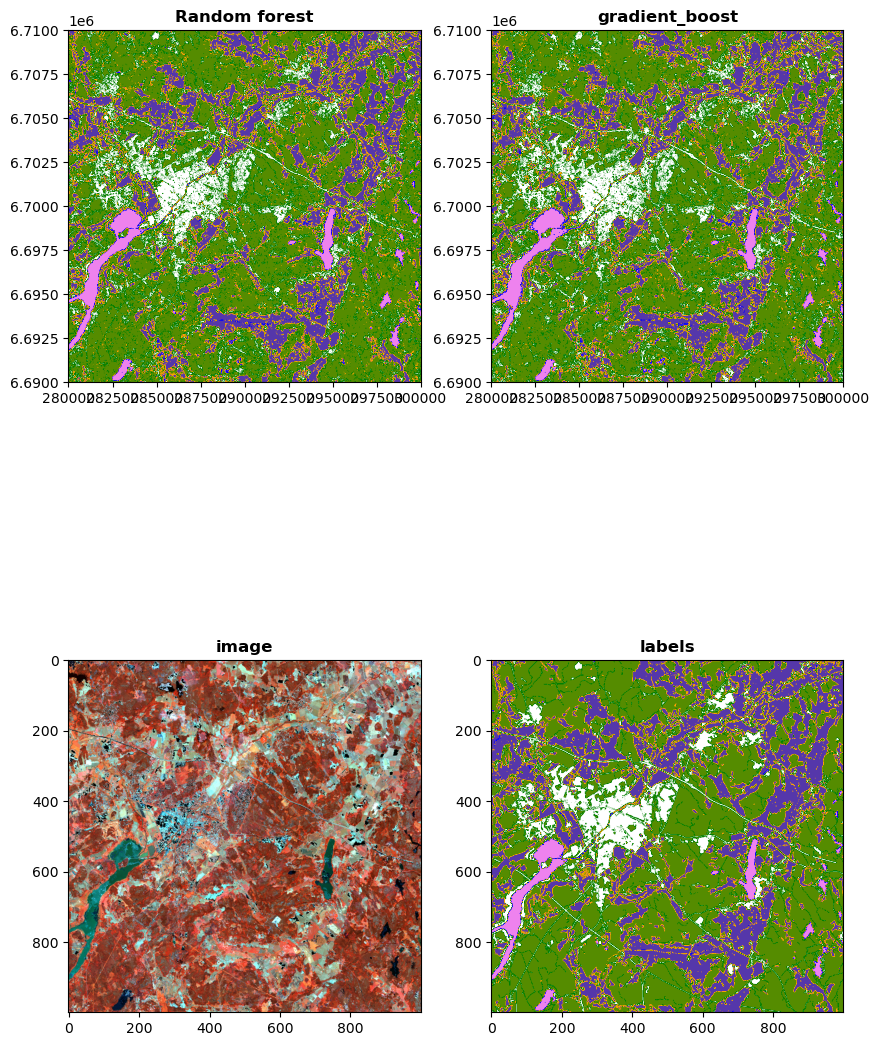

In [28]:
# Create a subplot for 6 images: 4 classification, 1 data image and 1 training labels. 
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10,15))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white","green","orange","blue","violet"])

# The prediction results
rf_results = rasterio.open(os.path.join(outputBaseFolder,'classification_random_forest.tif'))
show(rf_results, ax=ax[0, 0], cmap=cmap, title='Random forest')

gradient_boost_results = rasterio.open(os.path.join(outputBaseFolder,'classification_gradient_boosting.tif'))
show(gradient_boost_results, ax=ax[0, 1], cmap=cmap, title='gradient_boost')

# Plot the sentinel image 
nir, red, green = image_data[7,], image_data[3,], image_data[1,]
nirn, redn, greenn = normalize(nir), normalize(red), normalize(green)
stacked = np.stack((nirn, redn, greenn))
show(stacked, ax=ax[1,0], title='image') 

# Labels 
show(labels_data, ax=ax[1,1], cmap=cmap, title='labels')